In [2]:
# source .venv/bin/activate
from pythtb import TBModel, Lattice
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# define lattice vectors
lat_vecs = [[1, 0], [1 / 2, np.sqrt(3) / 2]]
# define coordinates of orbitals
orb_vecs = [[1 / 3, 1 / 3], [2 / 3, 2 / 3]]

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

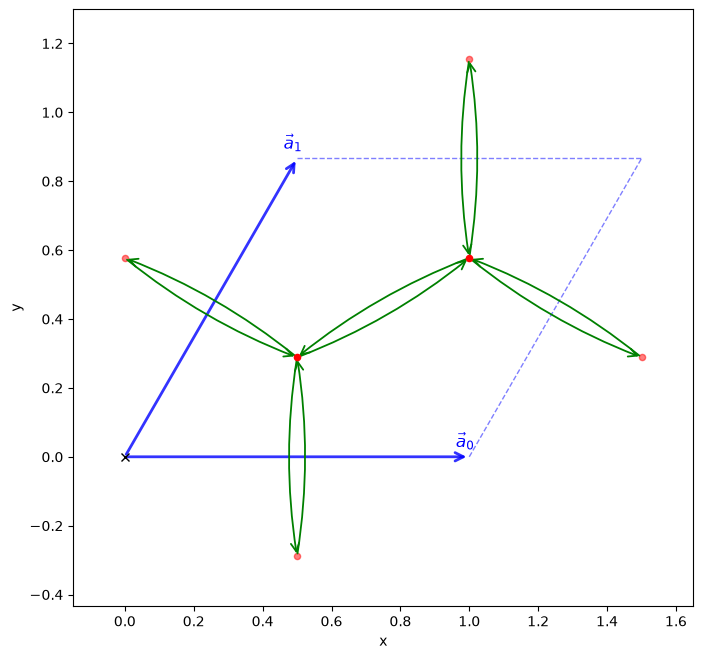

In [4]:
lat = Lattice(lat_vecs, orb_vecs, periodic_dirs=...)

# make two dimensional tight-binding graphene model
my_model = TBModel(lat)

# set model parameters
delta = 0.0
t = -1.0

# set on-site energies
my_model.set_onsite([-delta, delta])
# set hoppings (one for each connected pair of orbitals)
# (amplitude, i, j, [lattice vector to cell containing j])
my_model.set_hop(t, 0, 1, [0, 0])
my_model.set_hop(t, 1, 0, [1, 0])
my_model.set_hop(t, 1, 0, [0, 1])

# print(my_model)
my_model.visualize()

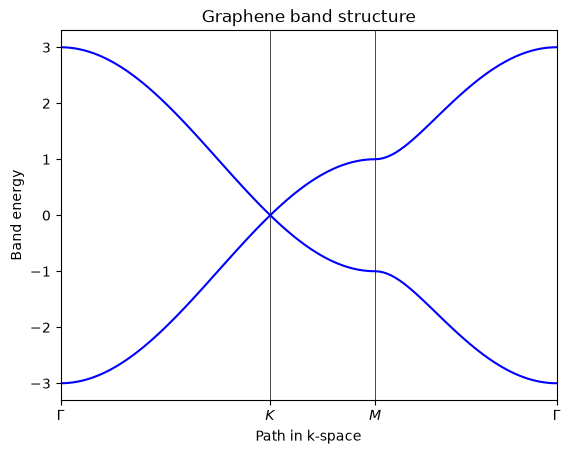

In [5]:

k_nodes = [[0, 0], [2 / 3, 1 / 3], [1 / 2, 1 / 2], [0, 0]]
k_node_labels = (r"$\Gamma $", r"$K$", r"$M$", r"$\Gamma $")
nk = 121

k_path, k_dist, k_node_dist = my_model.k_path(k_nodes, nk)


evals = my_model.solve_ham(k_path)


fig, ax = plt.subplots()

ax.set_xlim(k_node_dist[0], k_node_dist[-1])
ax.set_xticks(k_node_dist)
ax.set_xticklabels(k_node_labels)

for n in range(len(k_node_dist)):
    ax.axvline(x=k_node_dist[n], linewidth=0.5, color="k")

ax.set_title("Graphene band structure")
ax.set_xlabel("Path in k-space")
ax.set_ylabel("Band energy")

# plot bands
ax.plot(k_dist, evals, c="b")
plt.show()